In [1]:
import os
import sys
import gc
import tensorflow as tf
from tensorflow import keras
from keras import layers, applications


sys.path.insert(0, "Devoir partie 2/code")
from visualization import (
    image_sample_by_class,
    distribution,
    confusion_matrices,
    classification_error_samples,
    error_confidence,
    learning_curve
    )


print(sys.executable)
# sys.executable = "./scripts/tf_gpu_env.fish
print("LD_LIBRARY_PATH contains nvidia:", "site-packages/nvidia" in os.environ.get("LD_LIBRARY_PATH",""))

USE_GPU = True
CLASS_NAMES = ['avion','auto','oiseau','chat','cerf',
               'chien','grenouille','cheval','navire','camion']
               
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "0"
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
if gpus and USE_GPU:
    tf.config.set_visible_devices(gpus[0], "GPU")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("No GPU detected by TensorFlow. CPU fallback.")


I0000 00:00:1775857869.918645  195489 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775857869.948411  195489 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775857870.625496  195489 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/bin/python3.11
LD_LIBRARY_PATH contains nvidia: False
GPUs: []
No GPU detected by TensorFlow. CPU fallback.


W0000 00:00:1775857871.447229  195489 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:

# Notebook  : Réseaux de Neurones Convolutionnels (CNN) pour la Classification d’Images
# Charger le dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalisation des images
x_train, x_test = x_train / 255.0, x_test / 255.0

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


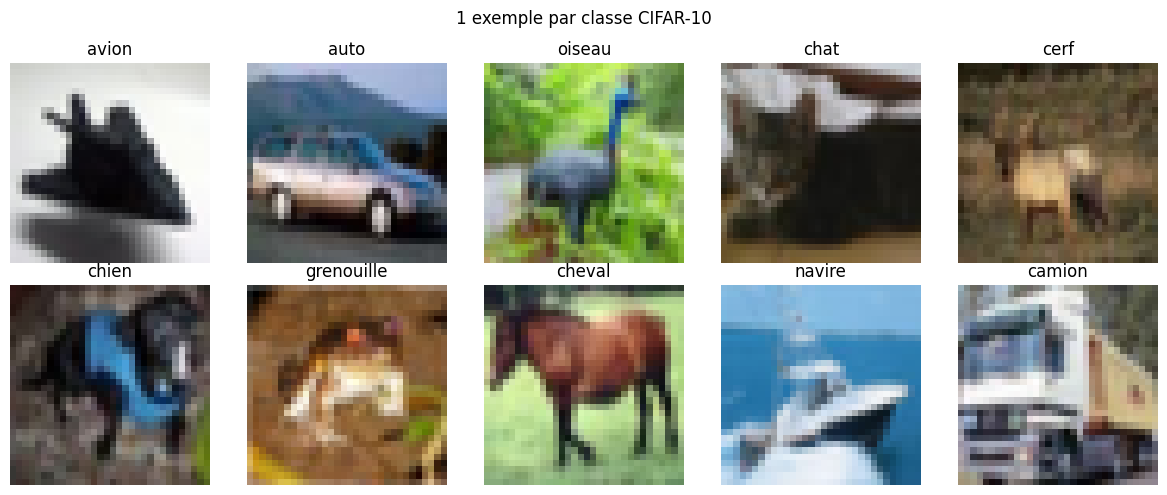

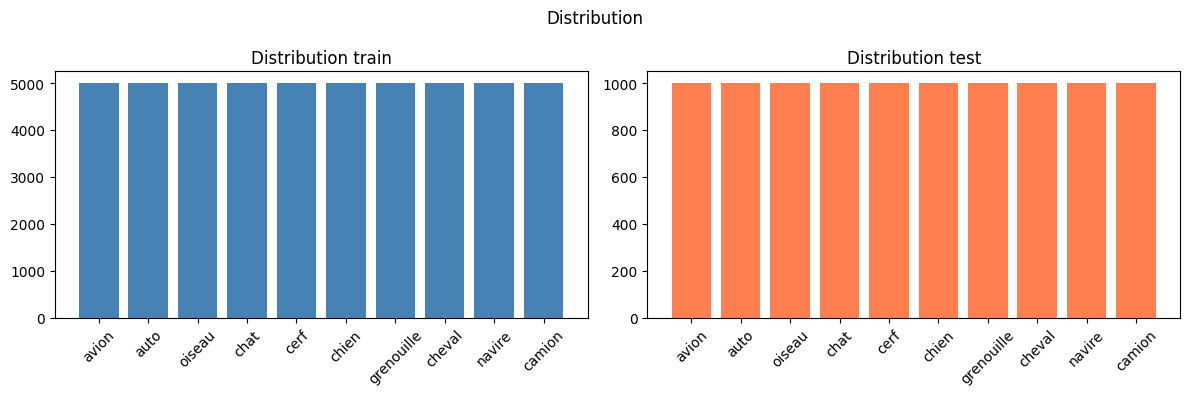

In [3]:
# Exemples d'images CIFAR-10 par classe
image_sample_by_class(x_train, y_train)
# Distribution des classes (train + test)
distribution(y_train, y_test)

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4453 - loss: 1.5123 - val_accuracy: 0.5239 - val_loss: 1.3061
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5964 - loss: 1.1453 - val_accuracy: 0.6177 - val_loss: 1.0742
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6572 - loss: 0.9810 - val_accuracy: 0.6517 - val_loss: 0.9837
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6970 - loss: 0.8661 - val_accuracy: 0.6714 - val_loss: 0.9348
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7281 - loss: 0.7817 - val_accuracy: 0.6948 - val_loss: 0.8826
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7497 - loss: 0.7118 - val_accuracy: 0.6937 - val_loss: 0.8981
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7701 - loss: 0.6542 - val_accuracy: 0.6912 - val_loss: 0.9297
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7890 - loss: 0.6021 - 

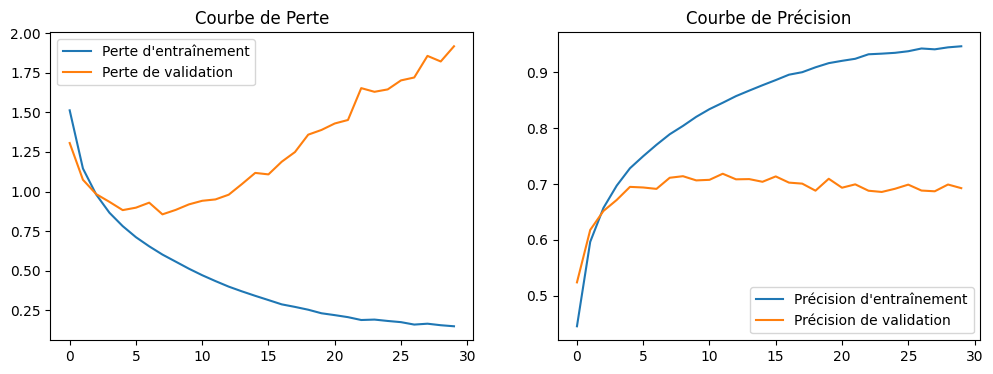

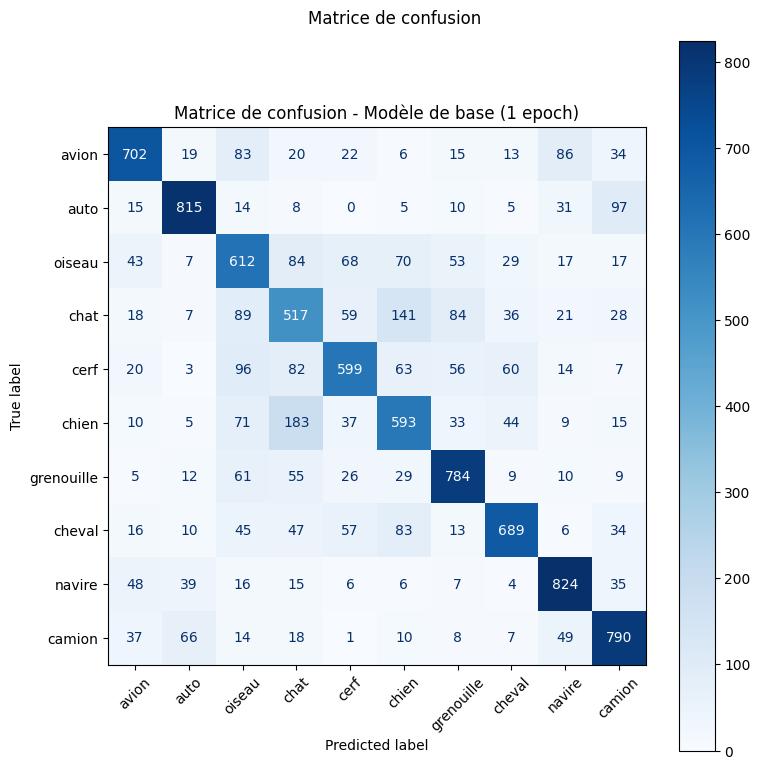

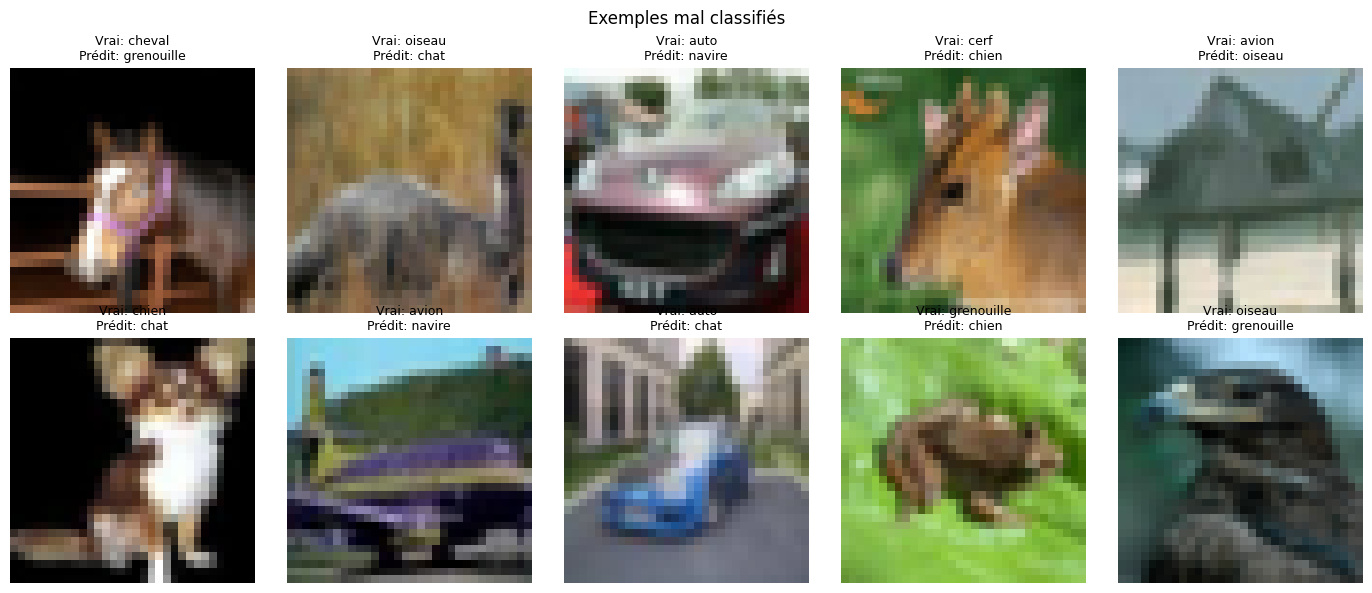

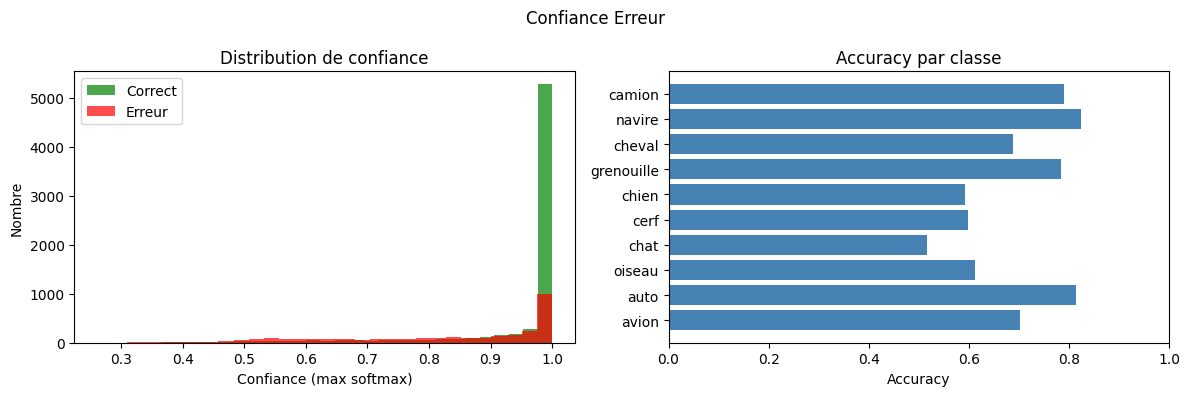

37182

In [ ]:
# Définition du modèle CNN de base
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5450 - loss: 1.2863 - val_accuracy: 0.4746 - val_loss: 1.8255
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6737 - loss: 0.9233 - val_accuracy: 0.5931 - val_loss: 1.2911
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7288 - loss: 0.7770 - val_accuracy: 0.6933 - val_loss: 0.8962
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7673 - loss: 0.6667 - val_accuracy: 0.6435 - val_loss: 1.0113
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8014 - loss: 0.5726 - val_accuracy: 0.7142 - val_loss: 0.8837
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8234 - loss: 0.5012 - val_accuracy: 0.7008 - val_loss: 0.9549
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8461 - loss: 0.4348 - val_accuracy: 0.6868 - val_loss: 1.0614
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8676 - loss: 0.3775 - 

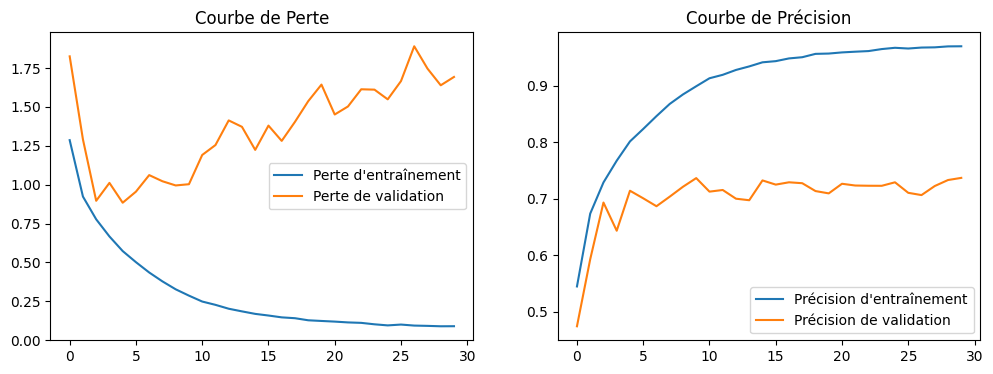

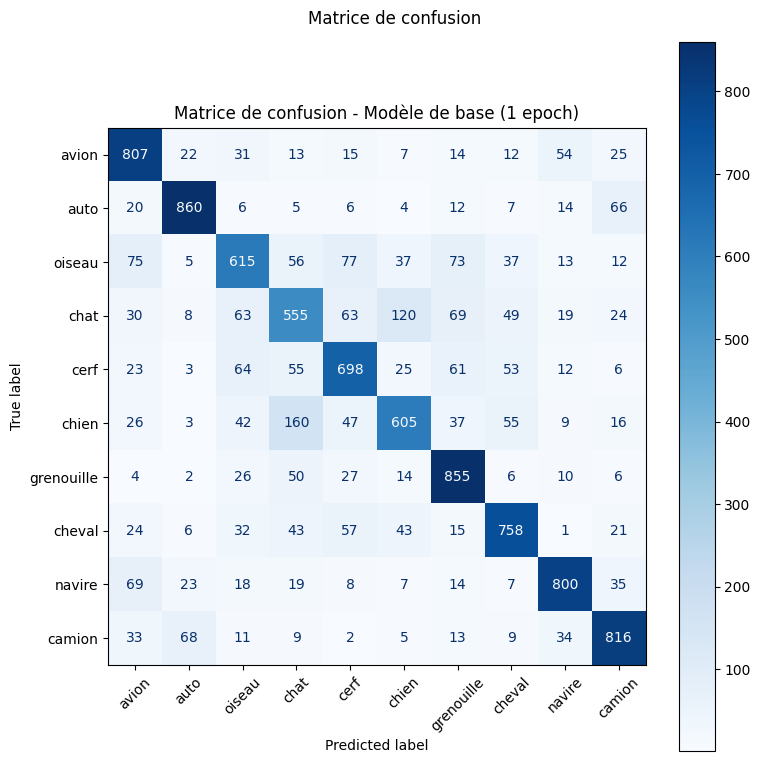

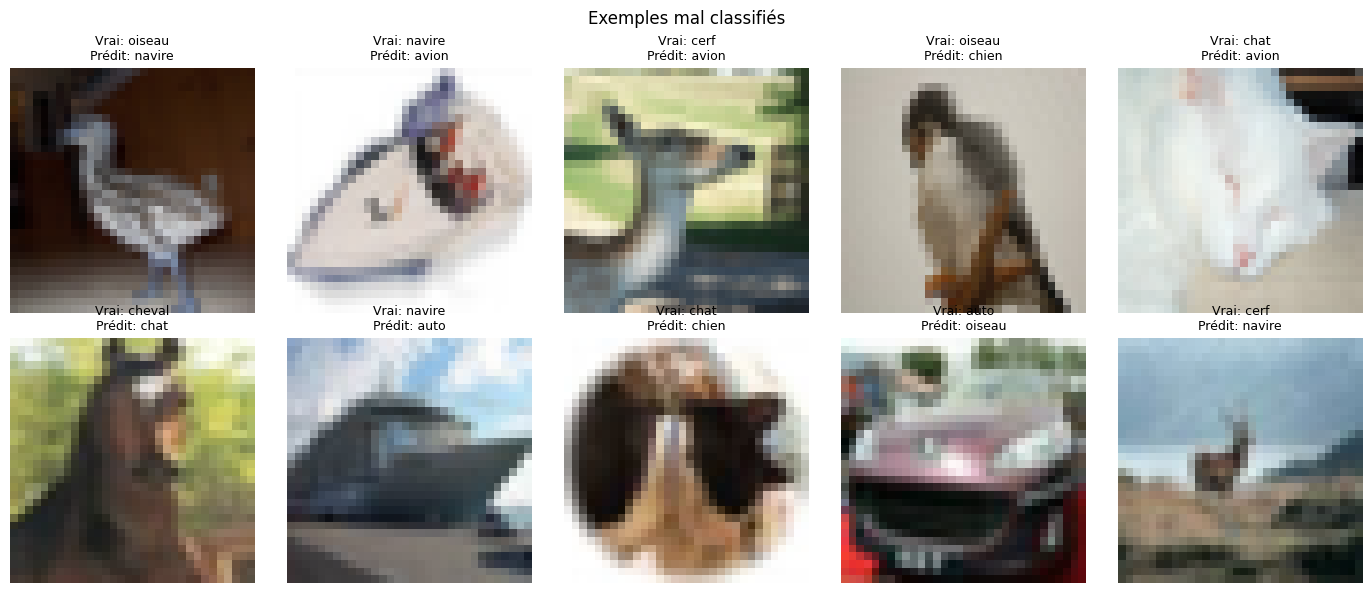

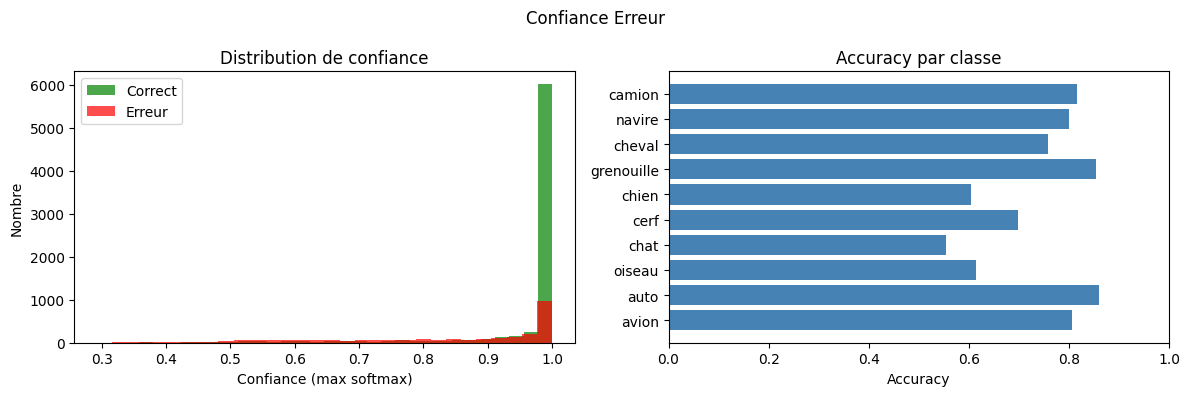

57989

In [ ]:
# Définition du modèle CNN avec BatchNormalisation(use_bias=False)
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3370 - loss: 1.8465 - val_accuracy: 0.4214 - val_loss: 1.8122
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4641 - loss: 1.4887 - val_accuracy: 0.4574 - val_loss: 1.7026
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5214 - loss: 1.3430 - val_accuracy: 0.5451 - val_loss: 1.3735
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5555 - loss: 1.2485 - val_accuracy: 0.5237 - val_loss: 1.3617
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5873 - loss: 1.1799 - val_accuracy: 0.5270 - val_loss: 1.4262
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6068 - loss: 1.1322 - val_accuracy: 0.6462 - val_loss: 0.9838
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6177 - loss: 1.0887 - val_accuracy: 0.6536 - val_loss: 0.9693
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6350 - loss: 1.0535 - 

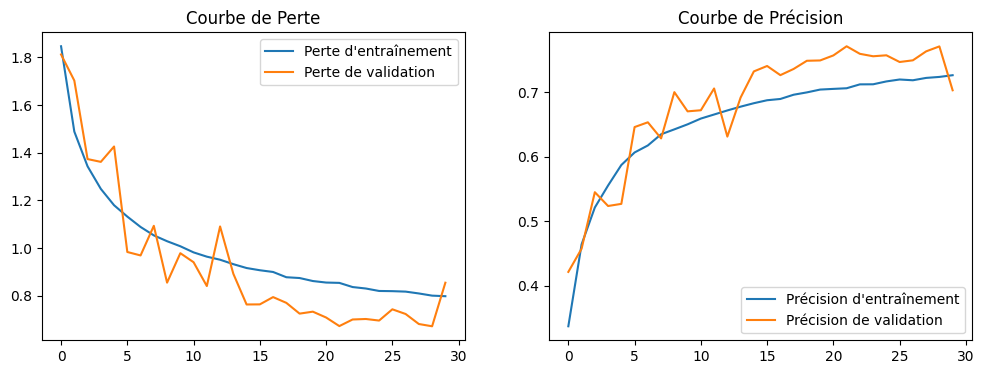

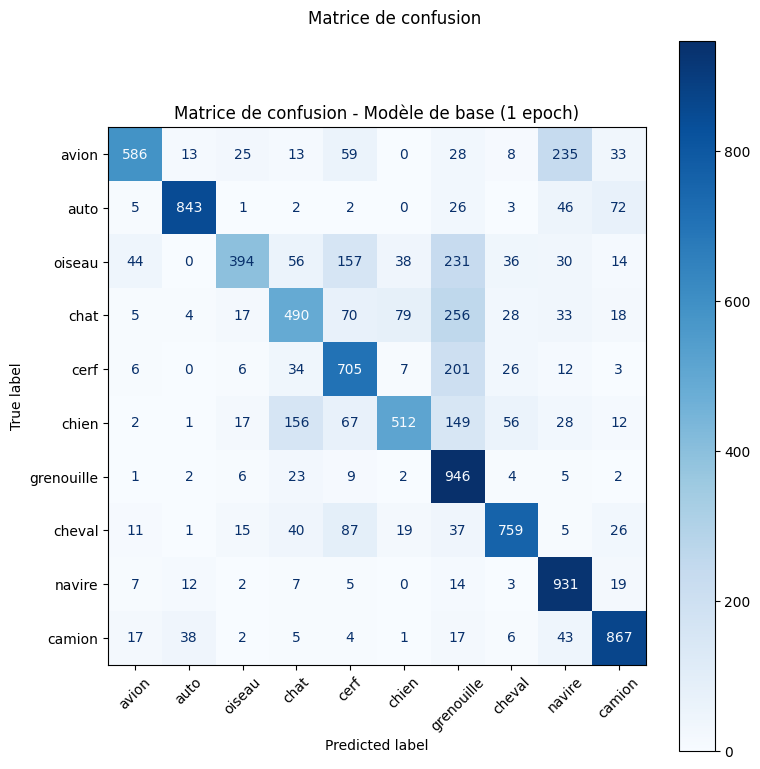

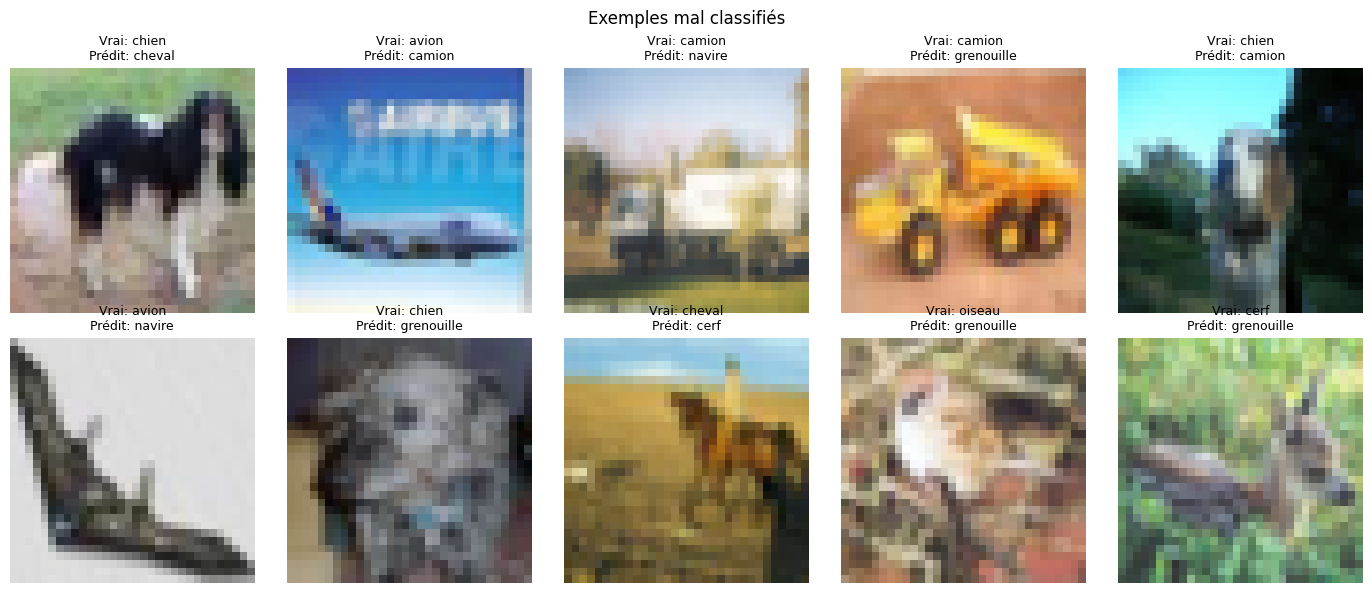

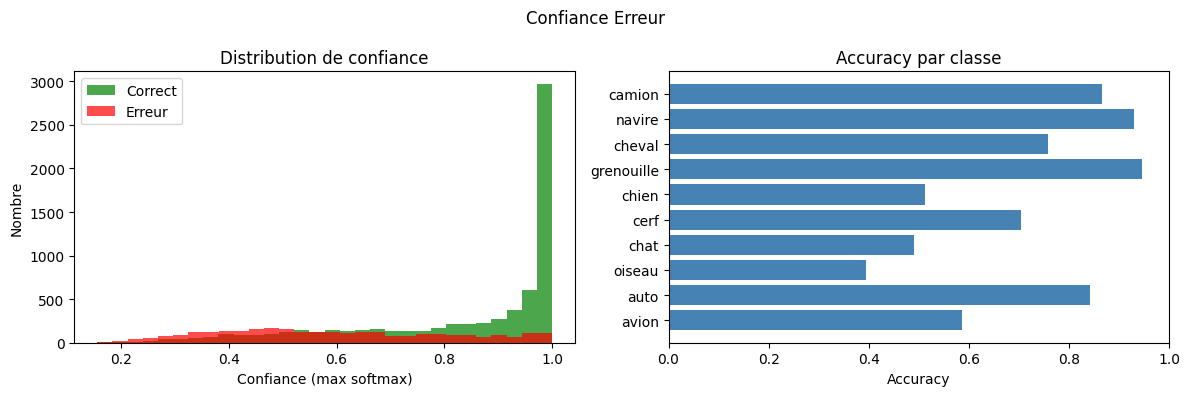

57017

In [ ]:
# Définition du modèle CNN avec BatchNormalisation(use_bias=False), Dropout(0.25, 0.5)
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3715 - loss: 1.8520 - val_accuracy: 0.5444 - val_loss: 1.2881
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5056 - loss: 1.3681 - val_accuracy: 0.5320 - val_loss: 1.3067
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5648 - loss: 1.2334 - val_accuracy: 0.6202 - val_loss: 1.0589
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5937 - loss: 1.1582 - val_accuracy: 0.6268 - val_loss: 1.0706
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6121 - loss: 1.0999 - val_accuracy: 0.6417 - val_loss: 1.0410
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6297 - loss: 1.0605 - val_accuracy: 0.5840 - val_loss: 1.2903
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6417 - loss: 1.0249 - val_accuracy: 0.6951 - val_loss: 0.8625
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6531 - loss: 1.0001 - 

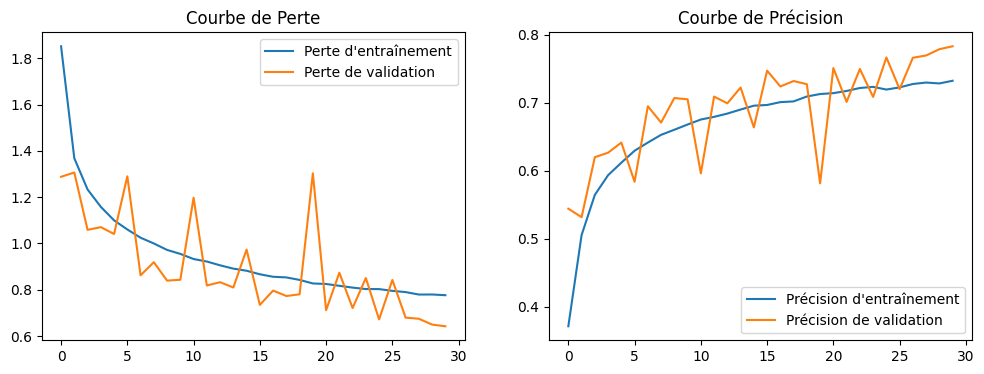

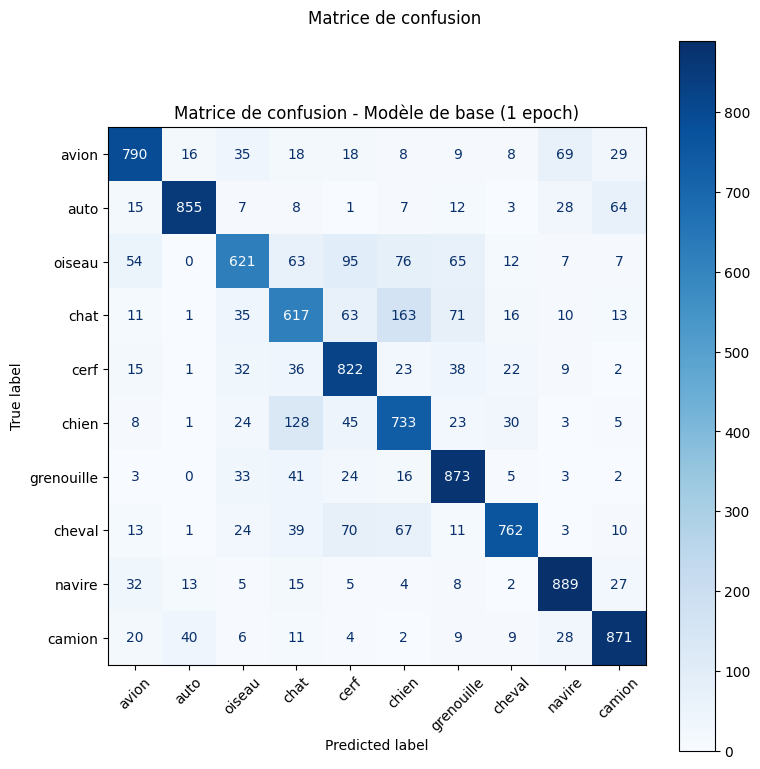

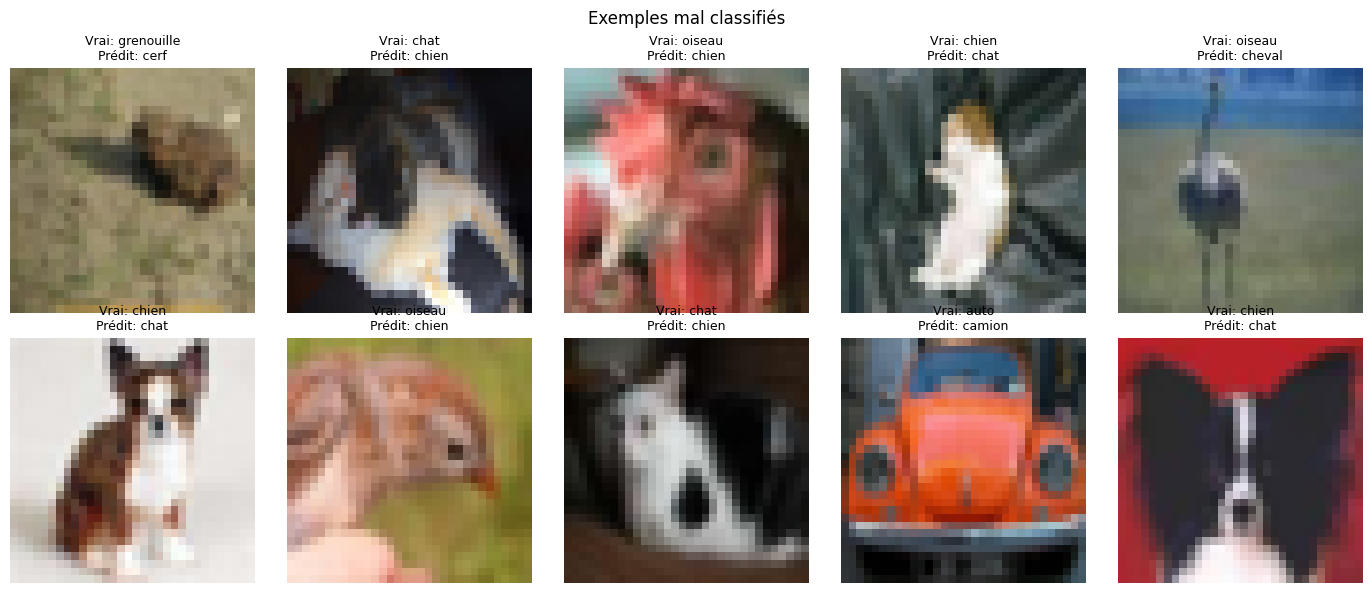

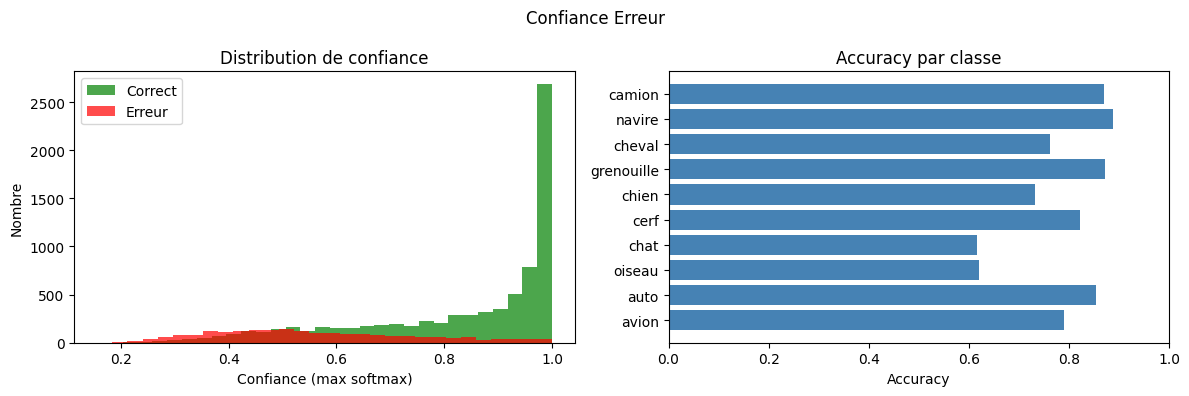

57538

In [ ]:
# Définition du modèle CNN avec BatchNormalisation(use_bias=False), Dropout(0.25, 0.5), activation="elu"
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='elu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='elu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='elu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3471 - loss: 1.8289 - val_accuracy: 0.4686 - val_loss: 1.4945
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4805 - loss: 1.4492 - val_accuracy: 0.5718 - val_loss: 1.2103
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5390 - loss: 1.3030 - val_accuracy: 0.5591 - val_loss: 1.2261
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5751 - loss: 1.2129 - val_accuracy: 0.6465 - val_loss: 0.9836
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6003 - loss: 1.1441 - val_accuracy: 0.6187 - val_loss: 1.0871
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6178 - loss: 1.0997 - val_accuracy: 0.6614 - val_loss: 0.9623
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6325 - loss: 1.0575 - val_accuracy: 0.6793 - val_loss: 0.9134
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6463 - loss: 1.0244 -

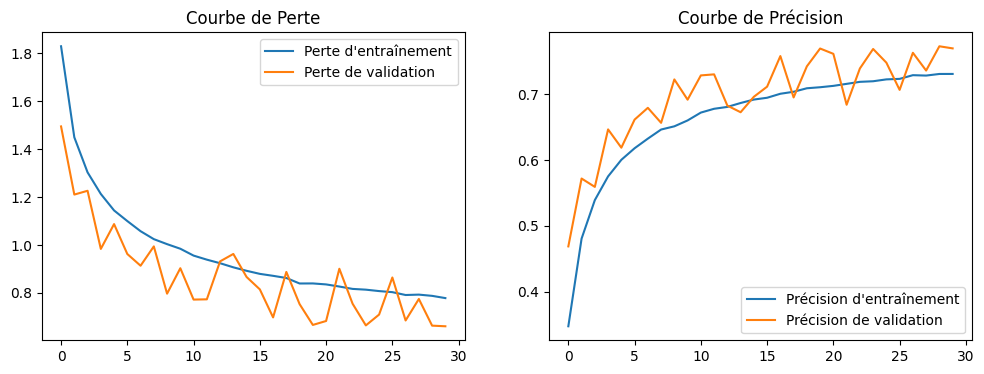

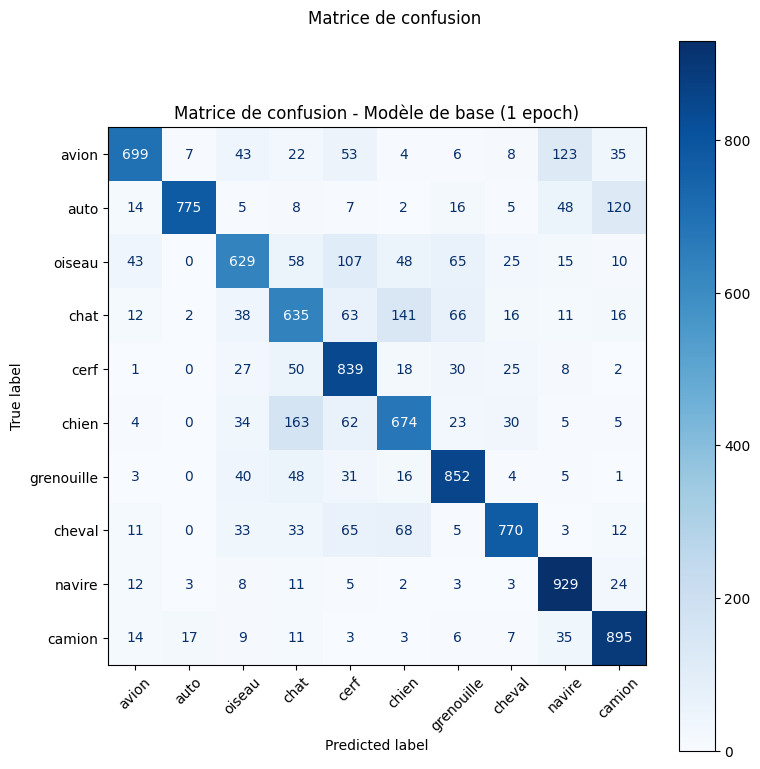

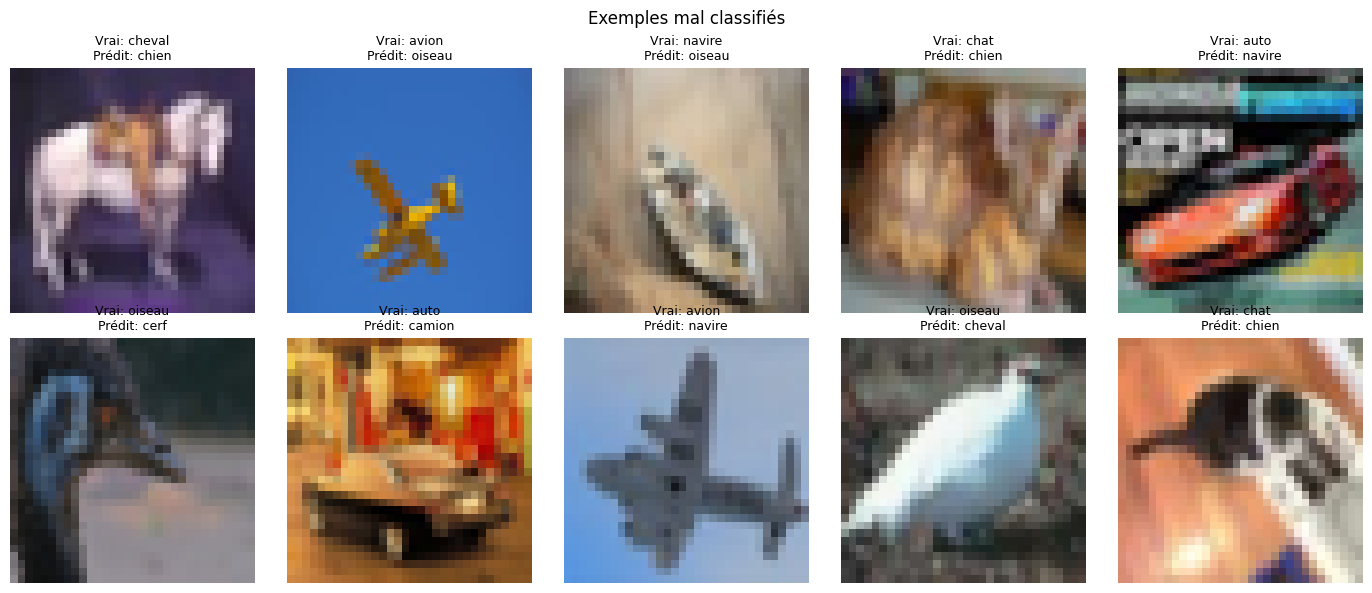

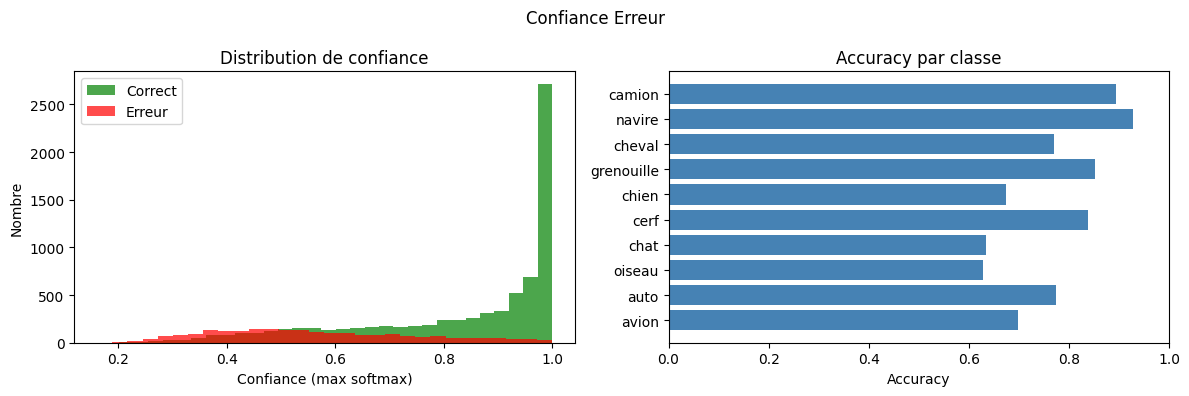

54265

In [ ]:
# Définition du modèle CNN avec 
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish"

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3439 - loss: 1.8226 - val_accuracy: 0.4734 - val_loss: 1.4273
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4644 - loss: 1.4939 - val_accuracy: 0.5361 - val_loss: 1.2908
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5318 - loss: 1.3115 - val_accuracy: 0.4461 - val_loss: 1.6824
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5742 - loss: 1.2055 - val_accuracy: 0.6192 - val_loss: 1.0798
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5974 - loss: 1.1405 - val_accuracy: 0.6444 - val_loss: 1.0040
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6169 - loss: 1.0965 - val_accuracy: 0.6311 - val_loss: 1.0378
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6296 - loss: 1.0566 - val_accuracy: 0.6468 - val_loss: 0.9946
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6416 - loss: 1.0298 -

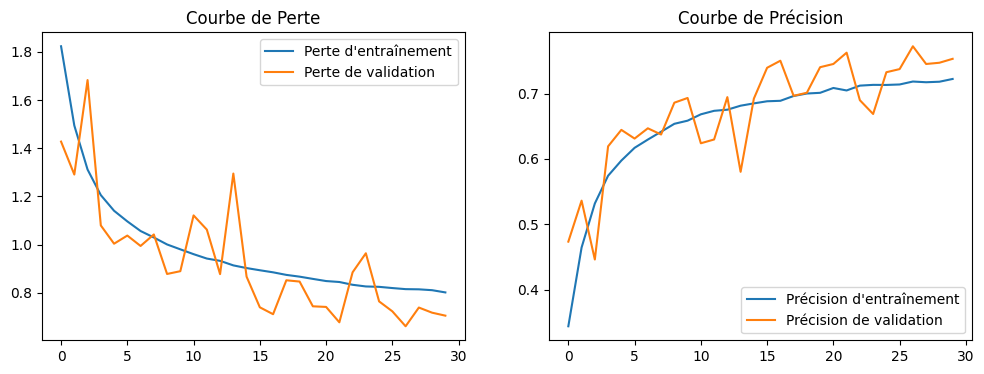

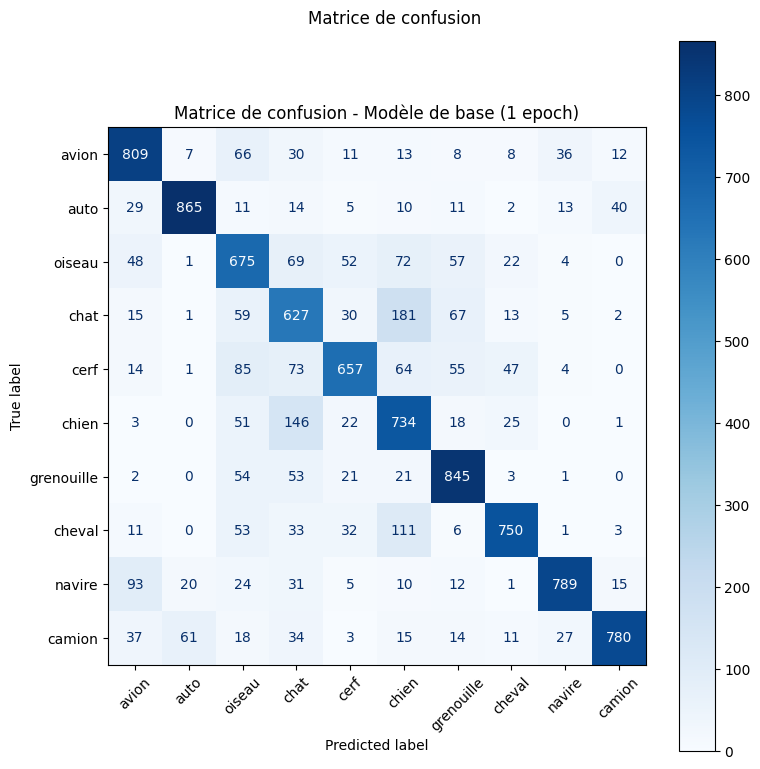

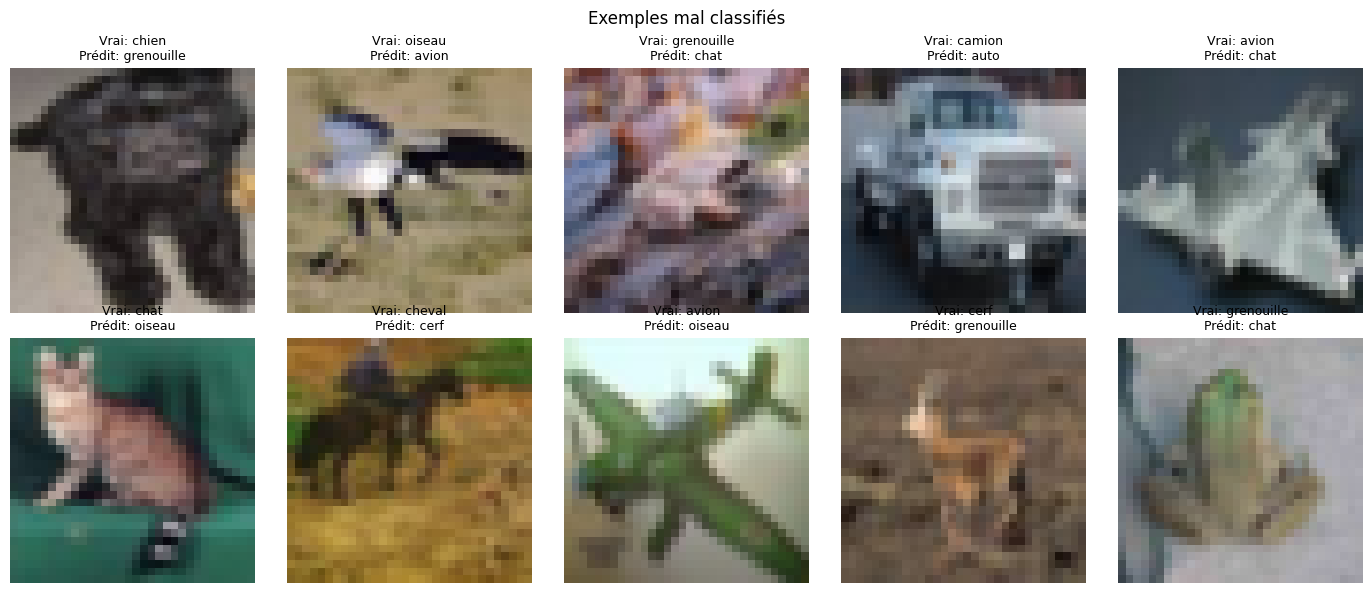

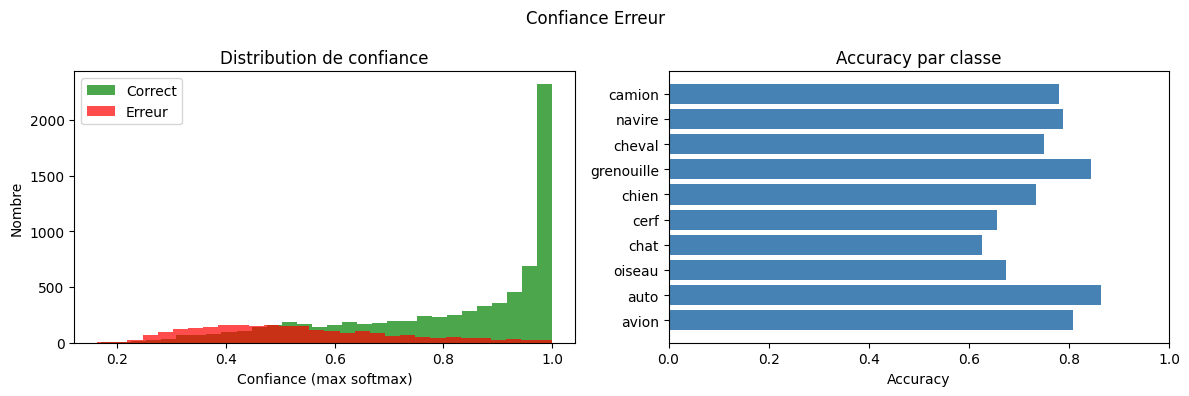

54304

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2610 - loss: 2.0405 - val_accuracy: 0.3770 - val_loss: 1.7845
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3945 - loss: 1.6927 - val_accuracy: 0.4850 - val_loss: 1.3724
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4854 - loss: 1.4432 - val_accuracy: 0.4558 - val_loss: 1.5147
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5456 - loss: 1.2897 - val_accuracy: 0.4237 - val_loss: 1.6603
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5797 - loss: 1.1963 - val_accuracy: 0.5910 - val_loss: 1.2067
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6059 - loss: 1.1299 - val_accuracy: 0.5784 - val_loss: 1.2664
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6253 - loss: 1.0828 - val_accuracy: 0.6430 - val_loss: 1.0120
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6414 - loss: 1

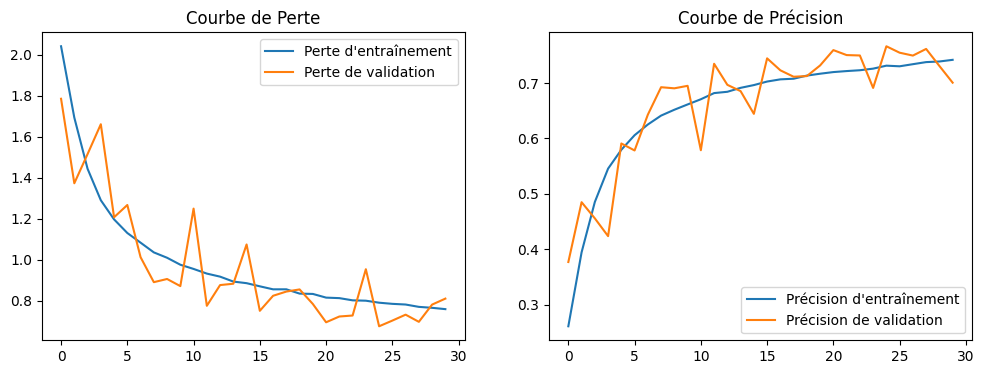

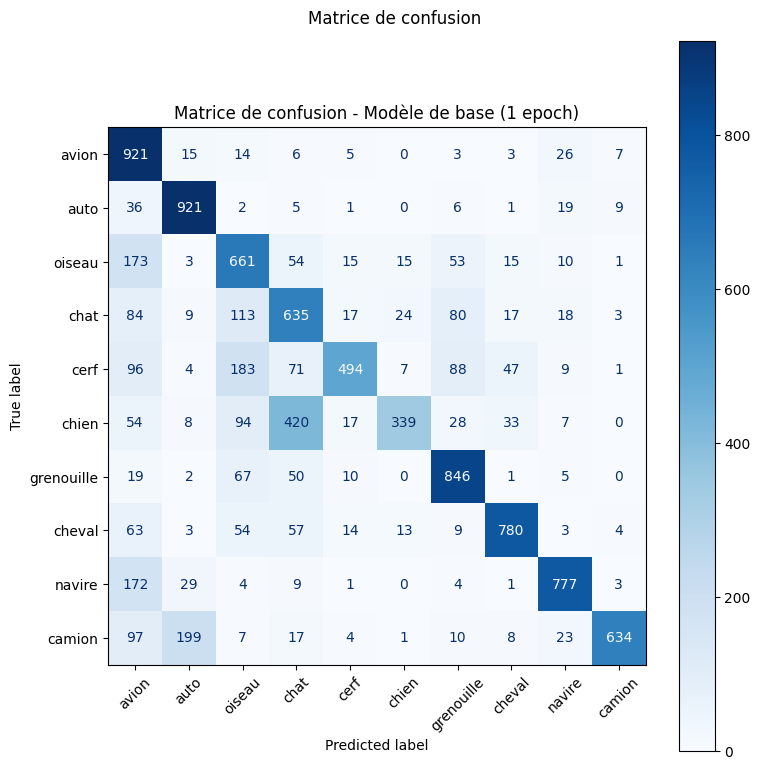

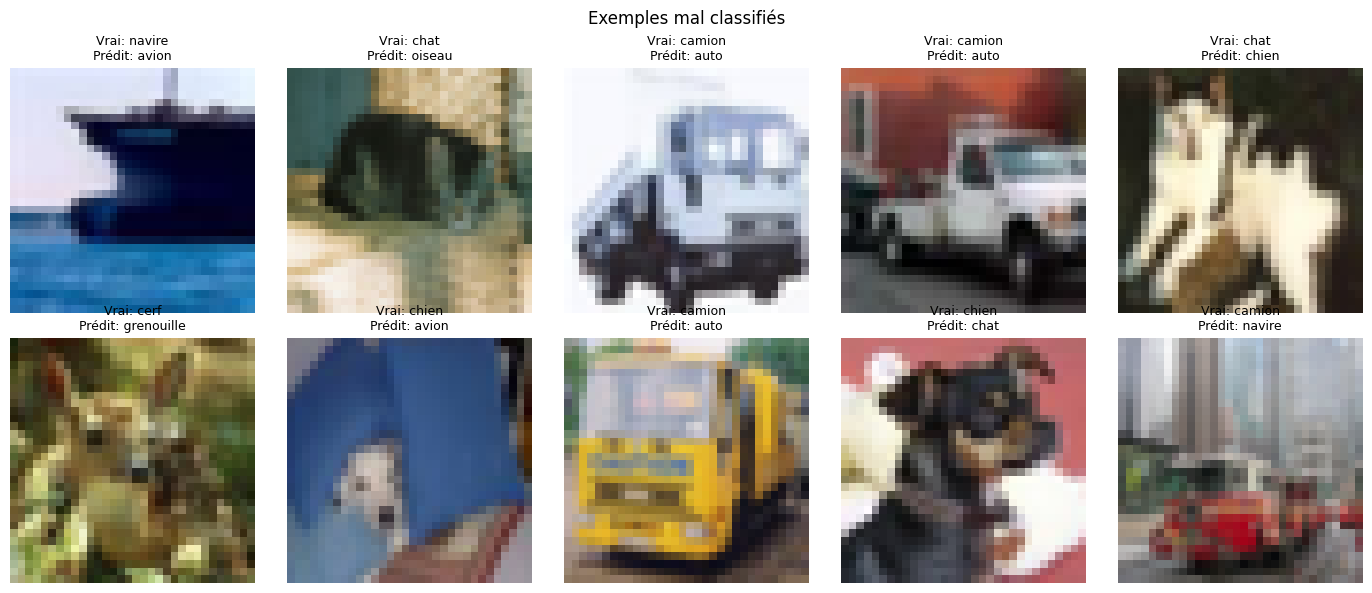

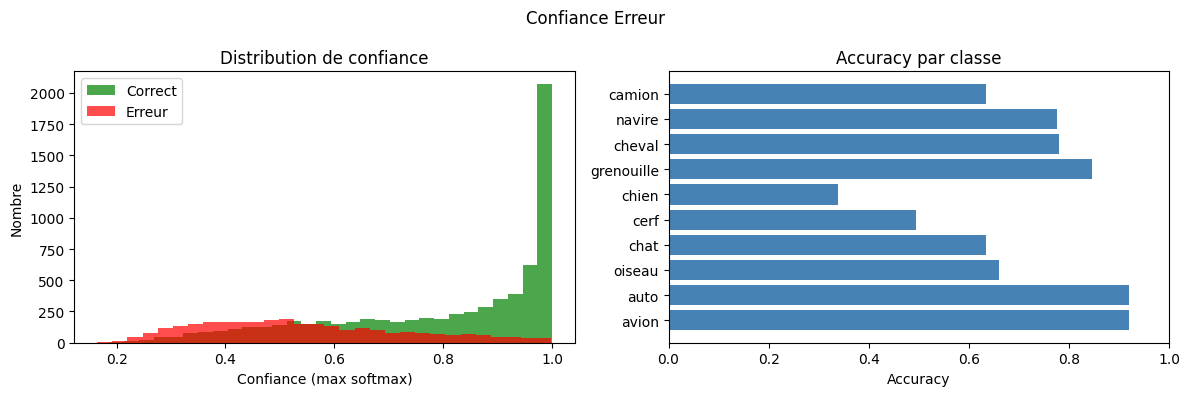

54544

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]

history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.2502 - loss: 2.0778 - val_accuracy: 0.3924 - val_loss: 1.8066
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3828 - loss: 1.7451 - val_accuracy: 0.4769 - val_loss: 1.5387
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4531 - loss: 1.5538 - val_accuracy: 0.5484 - val_loss: 1.3015
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5252 - loss: 1.3660 - val_accuracy: 0.5645 - val_loss: 1.2620
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5716 - loss: 1.2451 - val_accuracy: 0.6161 - val_loss: 1.1599
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6018 - loss: 1.1699 - val_accuracy: 0.6697 - val_loss: 0.9903
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6238 - loss: 1.1131 - val_accuracy: 0.7002 - val_loss: 0.9050
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6390 - loss: 1

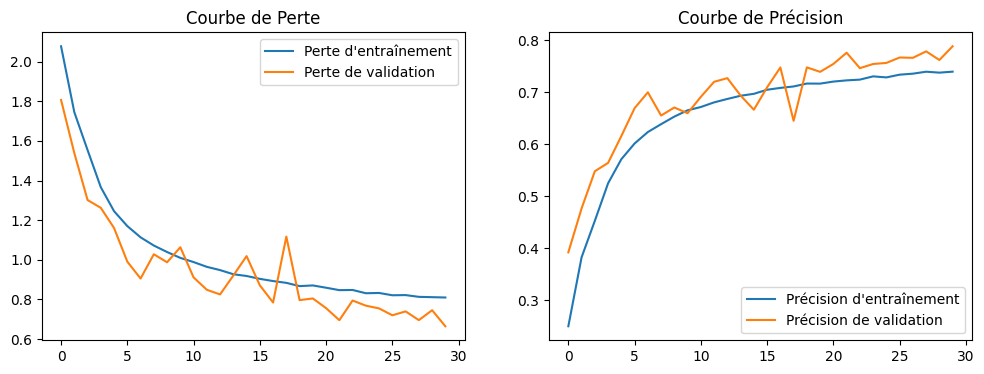

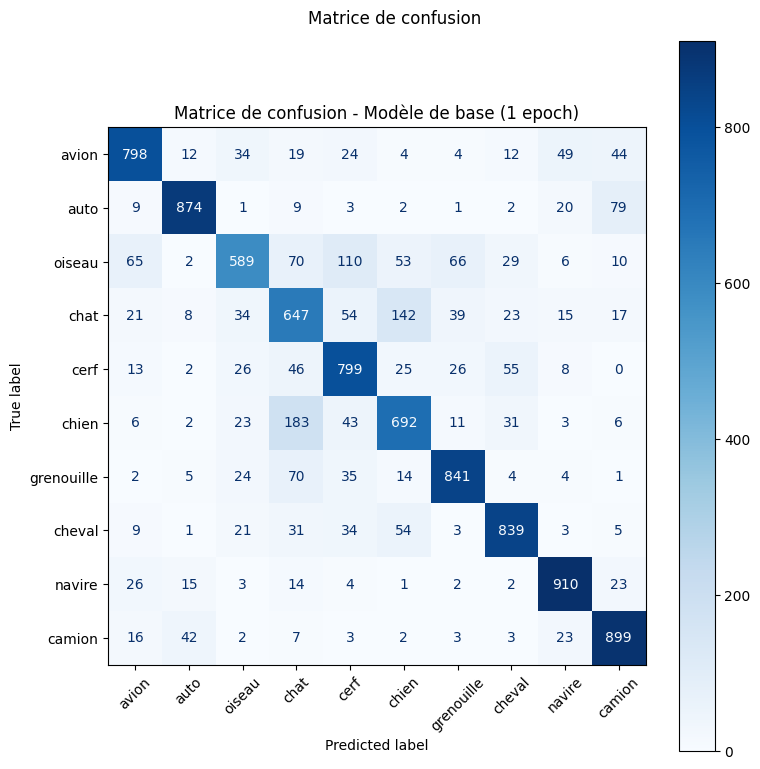

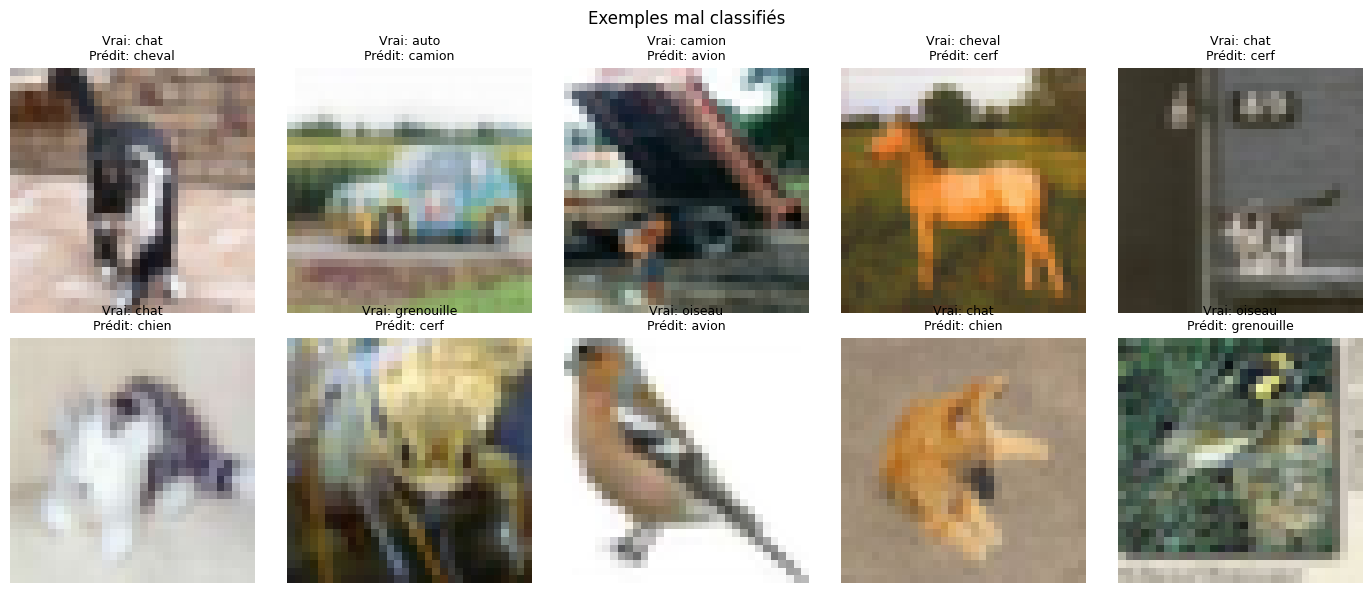

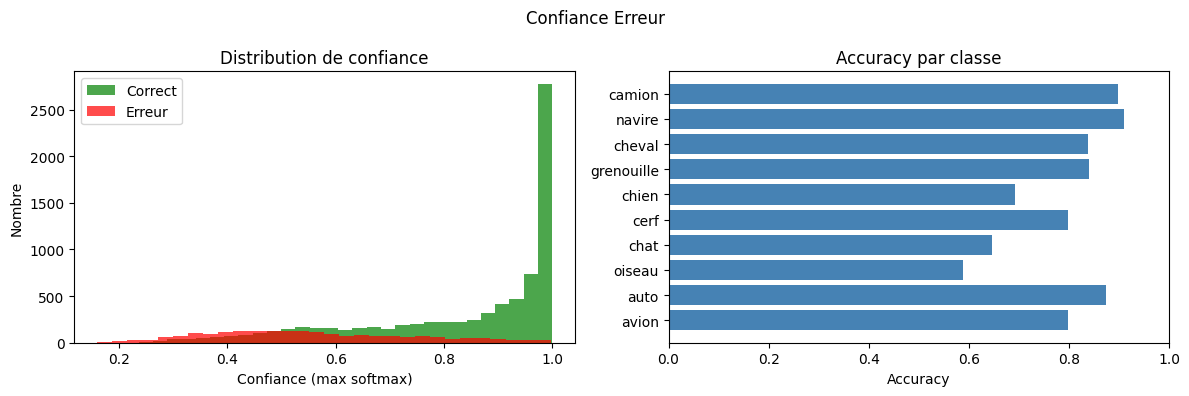

54405

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]

history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.2591 - loss: 2.0691 - val_accuracy: 0.4128 - val_loss: 1.6754
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.4350 - loss: 1.5995 - val_accuracy: 0.5381 - val_loss: 1.3136
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.5395 - loss: 1.3348 - val_accuracy: 0.5908 - val_loss: 1.1776
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6089 - loss: 1.1551 - val_accuracy: 0.6773 - val_loss: 0.9702
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6692 - loss: 0.9958 - val_accuracy: 0.7277 - val_loss: 0.8154
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7017 - loss: 0.9068 - val_accuracy: 0.7450 - val_loss: 0.7726
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7260 - loss: 0.8344 - val_accuracy: 0.7470 - val_loss: 0.7547
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7476 -

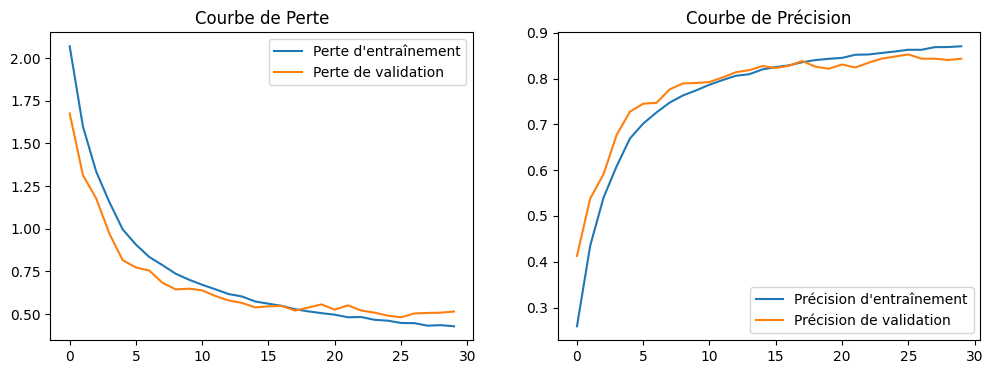

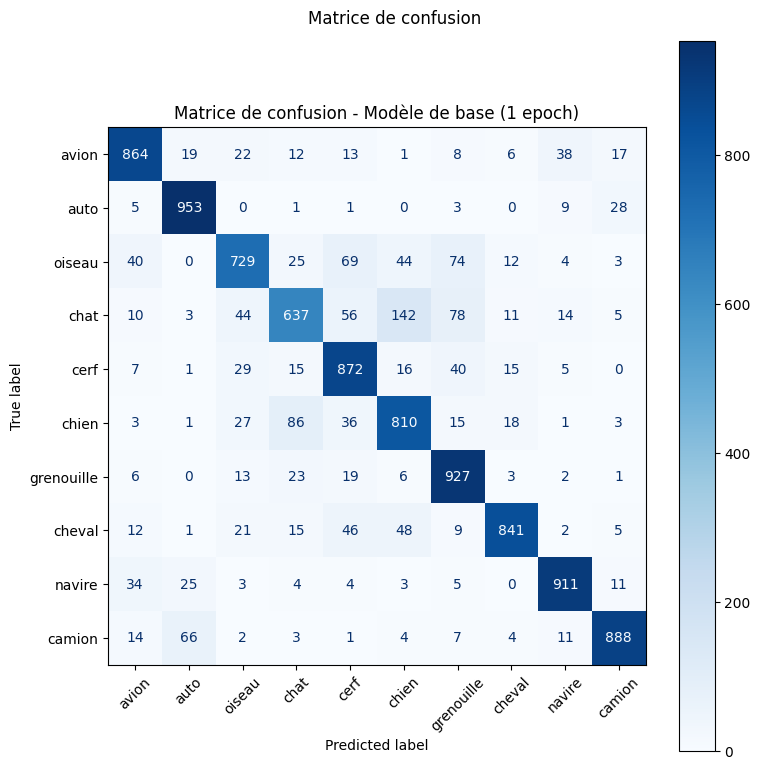

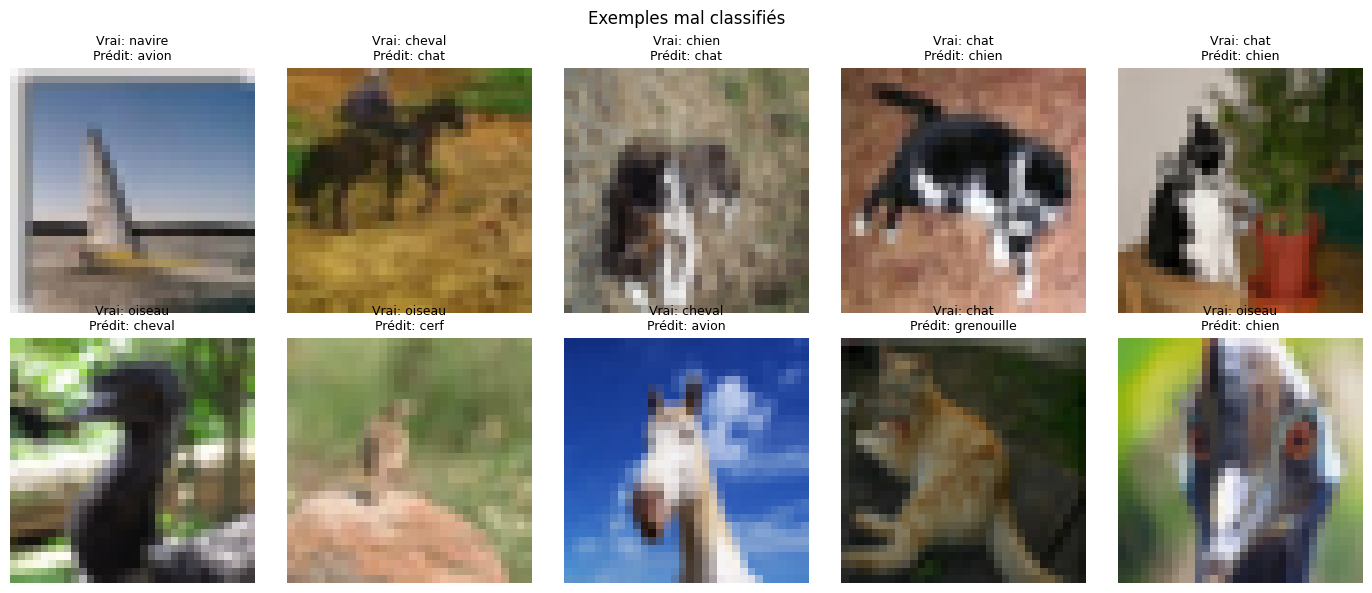

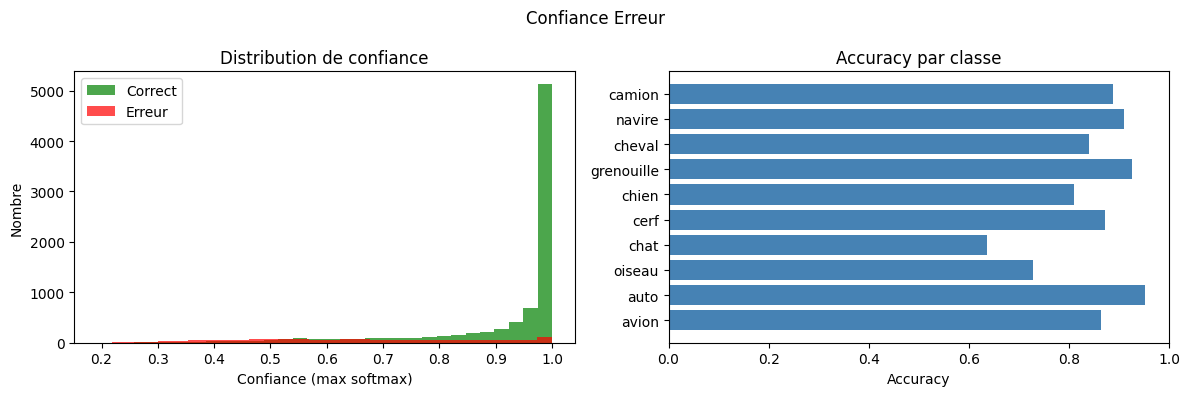

56307

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)
# - doublement de Conv2D

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]

history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)
# - doublement de Conv2D
# - doublement de Dense

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

/home/kilo/Work/Cours - UQO/concept-statistique/concept-stat-projet-1/.venv-stat/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.3371 - loss: 1.9267 - val_accuracy: 0.4721 - val_loss: 1.5095
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.5182 - loss: 1.4128 - val_accuracy: 0.6261 - val_loss: 1.0995
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6263 - loss: 1.1246 - val_accuracy: 0.6832 - val_loss: 0.9672
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6852 - loss: 0.9639 - val_accuracy: 0.6222 - val_loss: 1.1445
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7176 - loss: 0.8698 - val_accuracy: 0.7310 - val_loss: 0.8153
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7441 - loss: 0.8023 - val_accuracy: 0.7650 - val_loss: 0.7249
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7616 - loss: 0.7453 - val_accuracy: 0.7570 - val_loss: 0.7486
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7774 -

In [ ]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense


model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(), kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('elu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

In [ ]:
# Question pour expérimenter l'Apprentissage par Transfert

# Charger le modèle pré-entraîné  VGG16
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Geler les poids du modèle pré-entraîné

# Ajouter une couche de classification personnalisée
transfer_model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation et entraînement du modèle avec transfert d’apprentissage
transfer_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entraînement rapide pour test
history_fit = transfer_model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_test, y_test))
y_pred = transfer_model.predict(x_test).argmax(axis=1)
y_proba = transfer_model.predict(x_test)

# Comparer la performance avec et sans transfert d’apprentissage
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(x_test, y_test, verbose=2)
print(f'Précision avec apprentissage par transfert : {test_acc_transfer:.4f}')

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, transfer_model
gc.collect()